## 1. Import Libraries

In [16]:
import os


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings

warnings.filterwarnings("ignore")

In [17]:
import numpy as np
import pandas as pd

## 2. Data Ingestion
Loading the dataset. For demonstration, if the dataset doesn't exist, we'll create a dummy dataset with the required schema.

In [18]:
df = pd.read_csv("D:\PROJECTS\ML\Online_fraud_detection\data\onlinefraud.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [20]:
df.size

69988820

In [21]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [22]:
df.duplicated

<bound method DataFrame.duplicated of          step      type      amount     nameOrig  oldbalanceOrg  \
0           1   PAYMENT     9839.64  C1231006815      170136.00   
1           1   PAYMENT     1864.28  C1666544295       21249.00   
2           1  TRANSFER      181.00  C1305486145         181.00   
3           1  CASH_OUT      181.00   C840083671         181.00   
4           1   PAYMENT    11668.14  C2048537720       41554.00   
...       ...       ...         ...          ...            ...   
6362615   743  CASH_OUT   339682.13   C786484425      339682.13   
6362616   743  TRANSFER  6311409.28  C1529008245     6311409.28   
6362617   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
6362618   743  TRANSFER   850002.52  C1685995037      850002.52   
6362619   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
0             160296.36  M1979787155            0.00            0.00        

In [23]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [24]:
df.describe

<bound method NDFrame.describe of          step      type      amount     nameOrig  oldbalanceOrg  \
0           1   PAYMENT     9839.64  C1231006815      170136.00   
1           1   PAYMENT     1864.28  C1666544295       21249.00   
2           1  TRANSFER      181.00  C1305486145         181.00   
3           1  CASH_OUT      181.00   C840083671         181.00   
4           1   PAYMENT    11668.14  C2048537720       41554.00   
...       ...       ...         ...          ...            ...   
6362615   743  CASH_OUT   339682.13   C786484425      339682.13   
6362616   743  TRANSFER  6311409.28  C1529008245     6311409.28   
6362617   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
6362618   743  TRANSFER   850002.52  C1685995037      850002.52   
6362619   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
0             160296.36  M1979787155            0.00            0.00        0   

In [25]:
df = df.drop(["nameOrig", "nameDest"], axis=1)

In [26]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [27]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [28]:
df = df.drop(["isFlaggedFraud"], axis=1)

In [29]:
df = df.sample(100000, random_state=42)

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

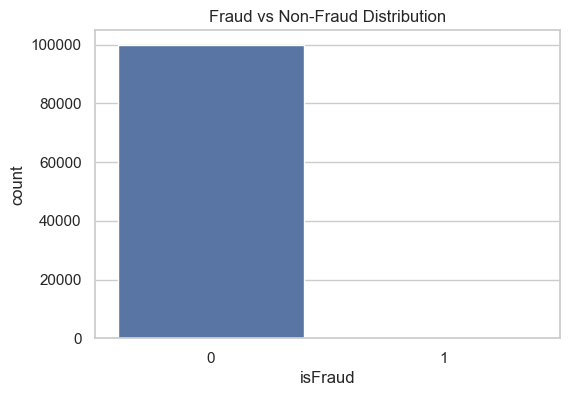

isFraud
0    99.859
1     0.141
Name: proportion, dtype: float64


In [31]:
plt.figure(figsize=(6, 4))
sns.countplot(x="isFraud", data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

print(df["isFraud"].value_counts(normalize=True) * 100)

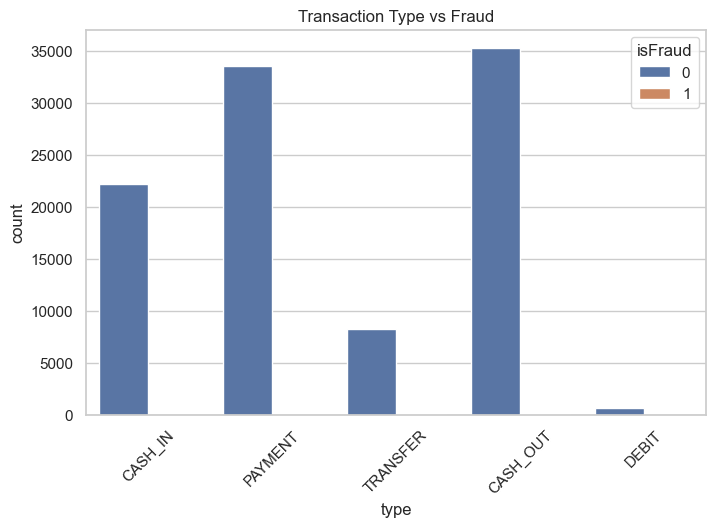

type
TRANSFER    0.946221
CASH_OUT    0.175468
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


In [32]:
plt.figure(figsize=(8, 5))
sns.countplot(x="type", hue="isFraud", data=df)
plt.title("Transaction Type vs Fraud")
plt.xticks(rotation=45)
plt.show()

# Percentage fraud per type
fraud_by_type = df.groupby("type")["isFraud"].mean() * 100
print(fraud_by_type.sort_values(ascending=False))

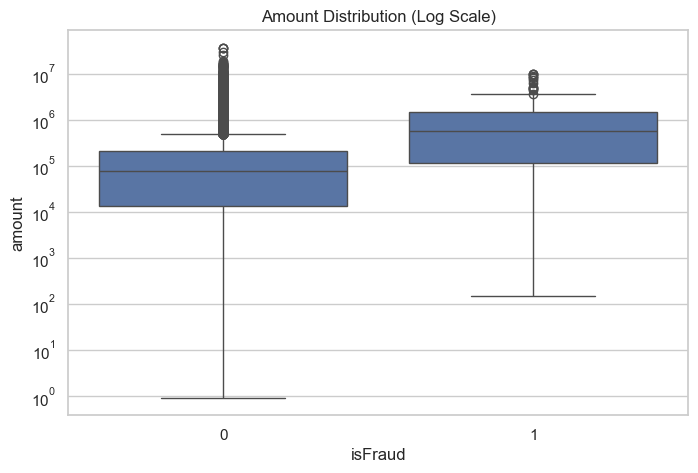

In [33]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="isFraud", y="amount", data=df)
plt.yscale("log")  # important due to skew
plt.title("Amount Distribution (Log Scale)")
plt.show()

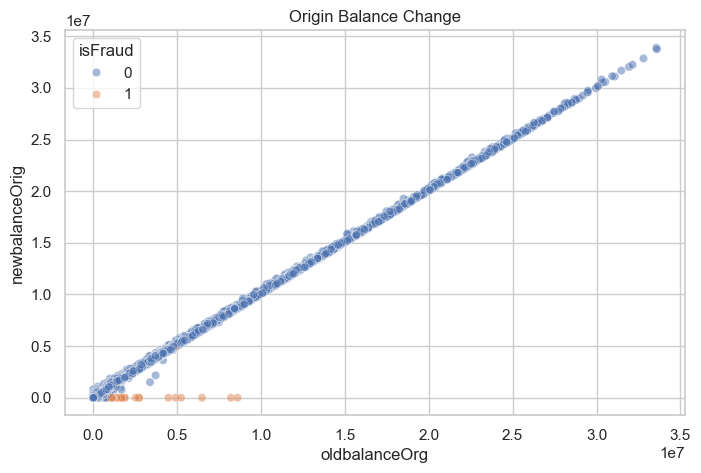

In [34]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x="oldbalanceOrg",
    y="newbalanceOrig",
    hue="isFraud",
    data=df.sample(50000),
    alpha=0.5,
)
plt.title("Origin Balance Change")
plt.show()

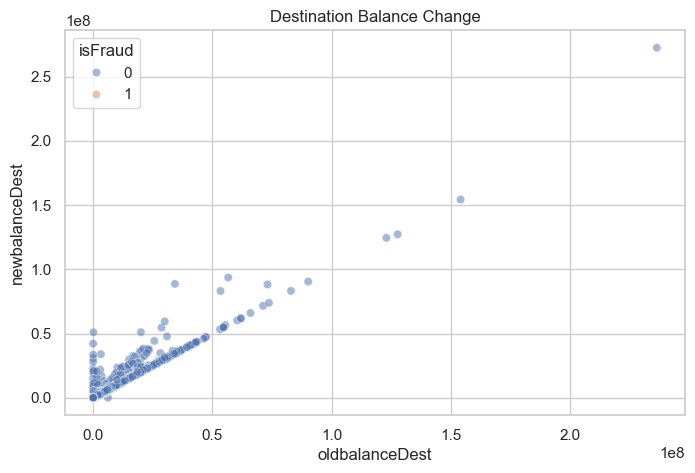

In [35]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x="oldbalanceDest",
    y="newbalanceDest",
    hue="isFraud",
    data=df.sample(50000),
    alpha=0.5,
)
plt.title("Destination Balance Change")
plt.show()

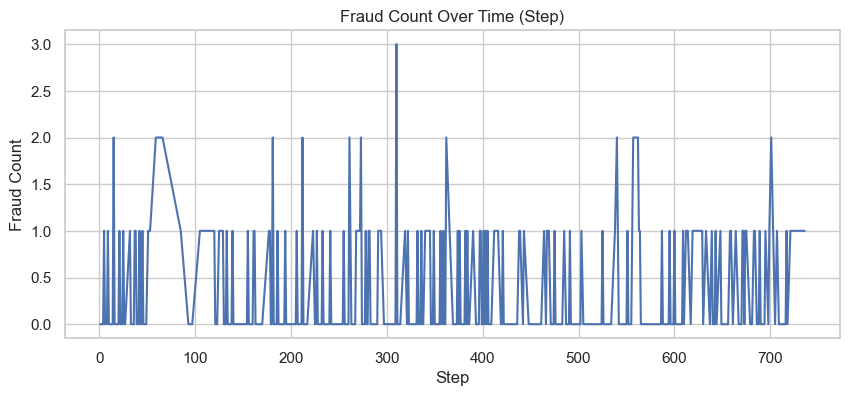

In [36]:
fraud_by_step = df.groupby("step")["isFraud"].sum()

plt.figure(figsize=(10, 4))
fraud_by_step.plot()
plt.title("Fraud Count Over Time (Step)")
plt.xlabel("Step")
plt.ylabel("Fraud Count")
plt.show()

In [37]:
df["isZeroOrig"] = (df["oldbalanceOrg"] == 0).astype(int)
df["isZeroDest"] = (df["oldbalanceDest"] == 0).astype(int)

print(
    "Zero Origin vs Fraud:\n",
    pd.crosstab(df["isZeroOrig"], df["isFraud"], normalize="index"),
)
print(
    "\nZero Destination vs Fraud:\n",
    pd.crosstab(df["isZeroDest"], df["isFraud"], normalize="index"),
)

Zero Origin vs Fraud:
 isFraud            0         1
isZeroOrig                    
0           0.997895  0.002105
1           1.000000  0.000000

Zero Destination vs Fraud:
 isFraud            0         1
isZeroDest                    
0           0.999273  0.000727
1           0.997656  0.002344


In [38]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

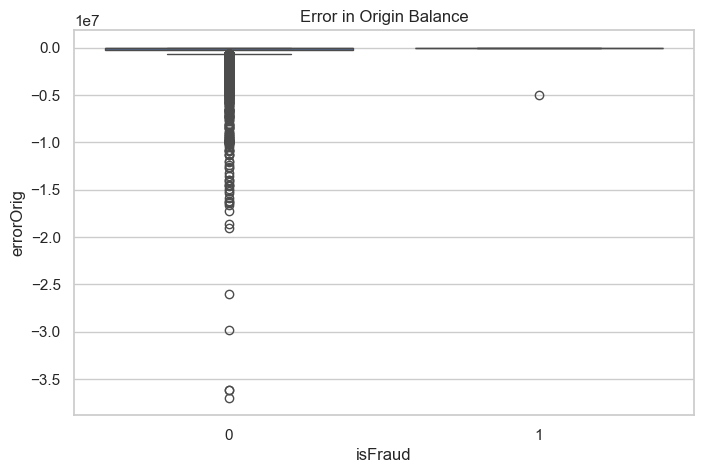

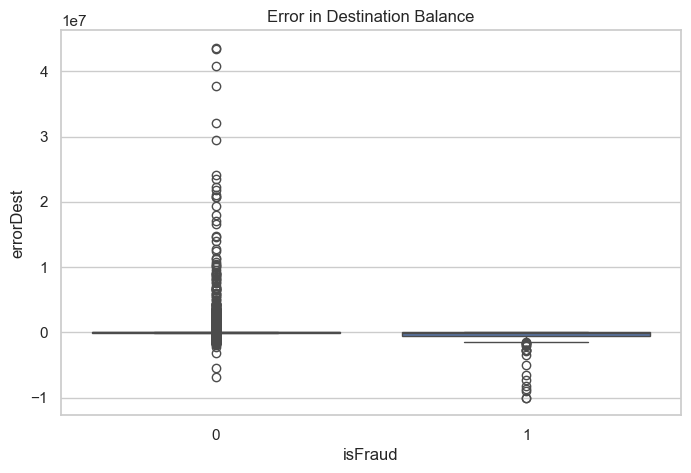

In [39]:
df["errorOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"] - df["amount"]
df["errorDest"] = df["newbalanceDest"] - df["oldbalanceDest"] - df["amount"]

plt.figure(figsize=(8, 5))
sns.boxplot(x="isFraud", y="errorOrig", data=df)
plt.title("Error in Origin Balance")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x="isFraud", y="errorDest", data=df)
plt.title("Error in Destination Balance")
plt.show()

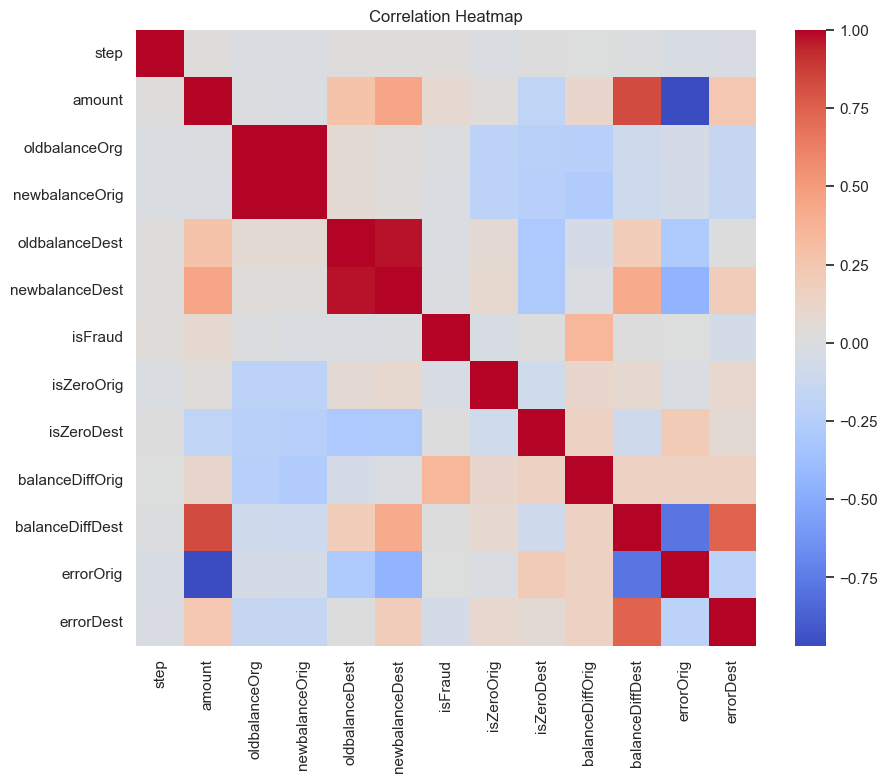

In [40]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 3. Feature Engineering
Creating derived features that capture the discrepancies in balances, which are strong indicators of fraud.

In [42]:
def create_derived_features(dataframe):
    df_copy = dataframe.copy()
    # Calculate balance errors
    df_copy["errorBalanceOrg"] = (
        df_copy["newbalanceOrig"] + df_copy["amount"] - df_copy["oldbalanceOrg"]
    )
    df_copy["errorBalanceDest"] = (
        df_copy["oldbalanceDest"] + df_copy["amount"] - df_copy["newbalanceDest"]
    )
    return df_copy


df_engineered = create_derived_features(df)
print("Engineered Features Added:")
display(df_engineered[["errorBalanceOrg", "errorBalanceDest"]].head())

Engineered Features Added:


,errorBalanceOrg,errorBalanceDest
3737323,660436.84,660436.84
264914,0.00,11647.08
85647,304528.42,304528.42
5899326,1551760.63,0.00
2544263,156344.60,156344.60


In [47]:
from imblearn.over_sampling import SMOTE

# Create the SMOTE object
smote = SMOTE(random_state=42)

# Fit and resample the data
X_resampled, y_resampled = smote.fit_resample(X, y)

# Now X_resampled and y_resampled are balanced

ValueError: could not convert string to float: 'CASH_OUT'

## 4. Train-Test Split

In [43]:
target_column = "isFraud"
X = df_engineered.drop(columns=[target_column])
y = df_engineered[target_column]

# Check if stratify is possible (needs at least 2 samples per class in dummy data)
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
except ValueError:
    print(
        "Stratified split failed (likely due to too few samples). Using standard split."
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (80000, 15)
X_test shape: (20000, 15)


## 5. Data Transformation (Preprocessing)
Building a ColumnTransformer to handle numerical scaling and categorical encoding.

In [44]:
numerical_columns = X_train.select_dtypes(exclude="object").columns.tolist()
categorical_columns = X_train.select_dtypes(include="object").columns.tolist()

num_pipeline = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

cat_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ("scaler", StandardScaler(with_mean=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, numerical_columns),
        ("cat", cat_pipeline, categorical_columns),
    ]
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"Transformed X_train shape: {X_train_transformed.shape}")

Transformed X_train shape: (80000, 19)


## 6. Model Training & Hyperparameter Tuning
We evaluate multiple models using GridSearchCV to find the best estimator based on ROC-AUC.

In [45]:
models = {
    "LogisticRegression": LogisticRegression(),
    "RandomForestClassifier": RandomForestClassifier(),
    "XGBClassifier": XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
}

# Parameters for GridSearch
params = {
    "LogisticRegression": {"C": [0.01, 0.1, 1], "solver": ["liblinear"]},
    "RandomForestClassifier": {"n_estimators": [50, 100], "max_depth": [5, 10]},
    "XGBClassifier": {
        "n_estimators": [50, 100],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 5],
    },
}

best_models = {}
model_scores = {}

# Since dummy data might be too small for CV=3, handle dynamically
cv_folds = min(3, len(y_train) // 2)
cv_folds = max(2, cv_folds)  # ensure at least 2 folds

for model_name, model in models.items():
    print(f"Training {model_name}...")
    gs = GridSearchCV(
        model, params[model_name], cv=cv_folds, scoring="roc_auc", n_jobs=-1
    )

    try:
        gs.fit(X_train_transformed, y_train)
        # Retrain on full training data with best params
        best_model = model.set_params(**gs.best_params_)
        best_model.fit(X_train_transformed, y_train)

        best_models[model_name] = best_model

        # Predict and score on test set
        y_test_pred = (
            best_model.predict_proba(X_test_transformed)[:, 1]
            if hasattr(best_model, "predict_proba")
            else best_model.predict(X_test_transformed)
        )

        try:
            score = roc_auc_score(y_test, y_test_pred)
        except ValueError:
            # Fallback if only one class is present in y_test
            score = 0.5

        model_scores[model_name] = score
        print(f"  Best Params: {gs.best_params_}")
        print(f"  Test ROC-AUC: {score:.4f}\n")
    except Exception as e:
        print(f"  Error training {model_name}: {e}\n")

if model_scores:
    best_model_name = max(model_scores, key=model_scores.get)
    final_best_model = best_models[best_model_name]
    print(
        f"==== Best Model: {best_model_name} with ROC-AUC {model_scores[best_model_name]:.4f} ===="
    )
else:
    print("No models were successfully trained.")

Training LogisticRegression...
  Best Params: {'C': 0.1, 'solver': 'liblinear'}
  Test ROC-AUC: 0.9774

Training RandomForestClassifier...
  Best Params: {'max_depth': 10, 'n_estimators': 50}
  Test ROC-AUC: 1.0000

Training XGBClassifier...
  Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
  Test ROC-AUC: 1.0000

==== Best Model: RandomForestClassifier with ROC-AUC 1.0000 ====


## 7. Model Evaluation
Evaluating the best model in depth using Precision, Recall, F1-Score, and ROC-AUC.

In [46]:
if model_scores:
    y_pred = final_best_model.predict(X_test_transformed)
    y_pred_proba = (
        final_best_model.predict_proba(X_test_transformed)[:, 1]
        if hasattr(final_best_model, "predict_proba")
        else y_pred
    )

    try:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    except ValueError:
        roc_auc = 0.5

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    metrics = {
        "ROC-AUC": roc_auc,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
    }

    print("Final Model Metrics:")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

Final Model Metrics:
ROC-AUC: 1.0000
Precision: 1.0000
Recall: 1.0000
F1_Score: 1.0000
